In [1]:
import sys
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")

import numpy as np
from openqkd.core.utils import (is_valid_state, tensor, apply_channel,
                                  dephasing_z, von_neumann_entropy,
                                  quantum_relative_entropy,
                                  conditional_entropy_key_rate)
from openqkd.core.qkd_param import QKDParam

# ── Teste 1: estado de Bell ───────────────────────────────────────────────────
phi_plus = np.array([1,0,0,1]) / np.sqrt(2)
rho_bell = np.outer(phi_plus, phi_plus)
assert is_valid_state(rho_bell), "Bell state inválido!"
print(f"✓ Estado de Bell válido | S(rho)={von_neumann_entropy(rho_bell):.4f} (esperado ~0.0)")

# ── Teste 2: entropia relativa trivial ────────────────────────────────────────
rho = np.eye(2) / 2   # estado maximamente misto
assert abs(quantum_relative_entropy(rho, rho)) < 1e-8, "D(rho||rho) deve ser 0!"
print(f"✓ D(rho||rho) = {quantum_relative_entropy(rho, rho):.2e} (esperado ~0)")

# ── Teste 3: canal identidade ─────────────────────────────────────────────────
kraus_id = [np.eye(2)]
rho_test = np.array([[0.7, 0.1],[0.1, 0.3]])
rho_out  = apply_channel(kraus_id, rho_test)
assert np.allclose(rho_test, rho_out), "Canal identidade falhou!"
print(f"✓ Canal identidade OK")

# ── Teste 4: QKDParam ─────────────────────────────────────────────────────────
qkd = QKDParam(dimA=2, dimB=2)
qkd.set_param("errorRate", 0.01)
qkd.summary()
assert qkd.dimAB == 4
print(f"✓ QKDParam OK | dimAB={qkd.dimAB}")

print("\n✅ Fase 2 concluída!")


✓ Estado de Bell válido | S(rho)=0.0000 (esperado ~0.0)
✓ D(rho||rho) = 0.00e+00 (esperado ~0)
✓ Canal identidade OK
QKDParam | dimA=2, dimB=2, dimAB=4
  params  : {'errorRate': 0.01}
  options : {'solver': 'CLARABEL', 'maxIter': 100, 'tol': 1e-08, 'verbose': False}
  modules : description=False, channel=False, keyrate=False
✓ QKDParam OK | dimAB=4

✅ Fase 2 concluída!


In [2]:
import numpy as np
import cvxpy as cp
from openqkd.solvers.fw2step import fw2step_solver

kraus_id = [np.eye(2)]
key_dim  = 2

# Pauli X como observável de restrição
X_pauli = np.array([[0., 1.], [1., 0.]])

# Teste 1: sem restrição de canal → mínimo = 0 (correto!)
def constraints_livre(rho_var):
    return [rho_var >> 0, cp.real(cp.trace(rho_var)) == 1]

plus = np.array([1., 1.]) / np.sqrt(2)
rho0 = np.outer(plus, plus)

r1 = fw2step_solver(rho0, kraus_id, constraints_livre, key_dim, verbose=False)
print(f"Teste 1 (sem restrição de canal)")
print(f"  Key rate : {r1['key_rate']:.6f} bits/round")
print(f"  Esperado : 0.000000  ← mínimo sobre todos os estados de 1 qubit\n")

# Teste 2: <X> = 1 força rho = |+><+| → key rate = 1 bit (correto!)
def constraints_ideal(rho_var):
    return [
        rho_var >> 0,
        cp.real(cp.trace(rho_var)) == 1,
        cp.real(cp.trace(X_pauli @ rho_var)) == 1.0   # <X> = 1 → rho = |+><+|
    ]

r2 = fw2step_solver(rho0, kraus_id, constraints_ideal, key_dim, verbose=True)
print(f"\nTeste 2 (<X> = 1, canal ideal)")
print(f"  Key rate : {r2['key_rate']:.6f} bits/round")
print(f"  Esperado : ~1.000000  ← log(2) = 1 bit")

# Teste 3: <X> = 0.8 → estado parcialmente coerente, resultado entre 0 e 1
def constraints_parcial(rho_var):
    return [
        rho_var >> 0,
        cp.real(cp.trace(rho_var)) == 1,
        cp.real(cp.trace(X_pauli @ rho_var)) == 0.8
    ]

r3 = fw2step_solver(rho0, kraus_id, constraints_parcial, key_dim, verbose=False)
print(f"\nTeste 3 (<X> = 0.8, canal com ruído)")
print(f"  Key rate : {r3['key_rate']:.6f} bits/round")
print(f"  Esperado : valor entre 0 e 1")


Teste 1 (sem restrição de canal)
  Key rate : 0.000000 bits/round
  Esperado : 0.000000  ← mínimo sobre todos os estados de 1 qubit

── Frank-Wolfe loop ──
  iter   1 | f(rho)=1.00000000 | FW gap=2.74e-08
  iter   2 | f(rho)=0.99999998 | FW gap=-2.11e-08
  Convergiu em 2 iterações.
── Dual certificate ──
  (modo simplificado)

  Upper bound : 0.99999998 bits/round
  Lower bound : 0.99999996 bits/round
  Epsilon     : 2.19e-08
  Leak EC     : 0.00000000 bits/round
  Key rate    : 0.99999996 bits/round

Teste 2 (<X> = 1, canal ideal)
  Key rate : 1.000000 bits/round
  Esperado : ~1.000000  ← log(2) = 1 bit

Teste 3 (<X> = 0.8, canal com ruído)
  Key rate : 0.531004 bits/round
  Esperado : valor entre 0 e 1


── Frank-Wolfe loop ──
  iter   1 | f(rho)=0.47232899 | FW gap=1.91e-02
  iter   2 | f(rho)=0.45967137 | FW gap=1.90e-04
  iter   3 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter   4 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter   5 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter   6 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter   7 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter   8 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter   9 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter  10 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter  11 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter  12 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter  13 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter  14 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter  15 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter  16 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter  17 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter  18 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter  19 | f(rho)=0.45960347 | FW gap=2.25e-04
  iter  20 | f(rho)=0.45960347 | FW gap=2.25e-

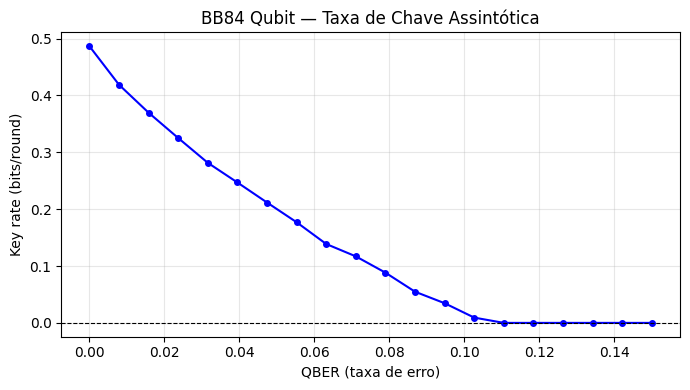

✅ Fase 4 concluída!


In [3]:
import sys
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")

from openqkd.presets.bb84_preset import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration

# ── Teste único: QBER = 1% ────────────────────────────────────────────────────
qkd_input = BasicBB84Alice2DPreset(error_rate=0.01)
qkd_input.options["verbose"] = True

results = MainIteration(qkd_input)
print(f"\n── Resultado ──────────────────────────────")
print(f"  QBER      : {results['qber_Z']:.4f}")
print(f"  Leak EC   : {results['leak_ec']:.6f} bits/round")
print(f"  Key rate  : {results['key_rate']:.6f} bits/round")

# ── Varredura de QBER (equivalente ao QKDPlot do MATLAB) ──────────────────────
import numpy as np
import matplotlib.pyplot as plt

error_rates = np.linspace(0, 0.15, 20)
key_rates   = []

for e in error_rates:
    qkd = BasicBB84Alice2DPreset(error_rate=e)
    r   = MainIteration(qkd)
    key_rates.append(max(0.0, r["key_rate"]))
    print(f"  e={e:.3f} → r={key_rates[-1]:.6f} bits/round")

plt.figure(figsize=(7, 4))
plt.plot(error_rates, key_rates, 'b-o', markersize=4)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel("QBER (taxa de erro)")
plt.ylabel("Key rate (bits/round)")
plt.title("BB84 Qubit — Taxa de Chave Assintótica")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("bb84_keyrate.png", dpi=150)
plt.show()
print("✅ Fase 4 concluída!")


  e=0.0000 | QBER_Z=0.0000 | leak_EC=0.0000 | key_rate=0.486525
  e=0.0062 | QBER_Z=0.0063 | leak_EC=0.0274 | key_rate=0.431855
  e=0.0125 | QBER_Z=0.0125 | leak_EC=0.0485 | key_rate=0.389687
  e=0.0187 | QBER_Z=0.0188 | leak_EC=0.0672 | key_rate=0.352298
  e=0.0250 | QBER_Z=0.0250 | leak_EC=0.0843 | key_rate=0.318018
  e=0.0312 | QBER_Z=0.0313 | leak_EC=0.1003 | key_rate=0.283335
  e=0.0375 | QBER_Z=0.0375 | leak_EC=0.1154 | key_rate=0.247357
  e=0.0437 | QBER_Z=0.0438 | leak_EC=0.1296 | key_rate=0.227472
  e=0.0500 | QBER_Z=0.0500 | leak_EC=0.1432 | key_rate=0.200340
  e=0.0562 | QBER_Z=0.0563 | leak_EC=0.1562 | key_rate=0.172116
  e=0.0625 | QBER_Z=0.0625 | leak_EC=0.1686 | key_rate=0.141839
  e=0.0687 | QBER_Z=0.0688 | leak_EC=0.1806 | key_rate=0.124541
  e=0.0750 | QBER_Z=0.0750 | leak_EC=0.1922 | key_rate=0.102467
  e=0.0812 | QBER_Z=0.0813 | leak_EC=0.2033 | key_rate=0.078751
  e=0.0875 | QBER_Z=0.0875 | leak_EC=0.2140 | key_rate=0.052002
  e=0.0937 | QBER_Z=0.0938 | leak_EC=0.2

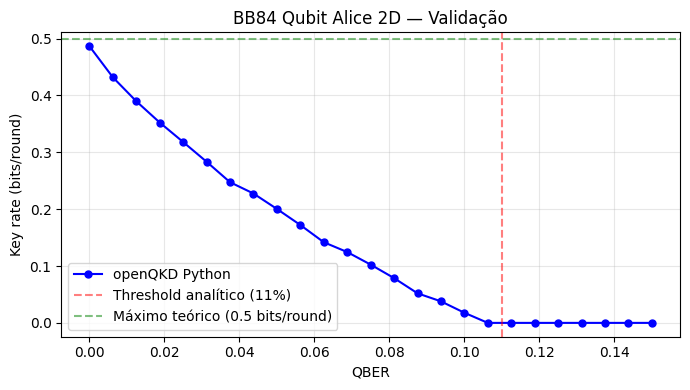

In [8]:
import sys
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")

import numpy as np
import matplotlib.pyplot as plt
from openqkd.presets.bb84_preset import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration

# Varredura de QBER — deve reproduzir Fig. 1 do user guide do openQKDsecurity
error_rates = np.linspace(0.0, 0.15, 25)
key_rates   = []

for e in error_rates:
    qkd = BasicBB84Alice2DPreset(error_rate=e)
    r   = MainIteration(qkd)
    kr  = max(0.0, r["key_rate"])
    key_rates.append(kr)
    print(f"  e={e:.4f} | QBER_Z={r['qber_Z']:.4f} | "
          f"leak_EC={r['leak_ec']:.4f} | key_rate={kr:.6f}")

# Threshold analítico Shor-Preskill: e* ≈ 0.110
threshold_idx = next(i for i, kr in enumerate(key_rates) if kr == 0.0)
print(f"\n  Threshold QBER ≈ {error_rates[threshold_idx-1]:.4f} (esperado ~0.110)")

plt.figure(figsize=(7, 4))
plt.plot(error_rates, key_rates, 'b-o', markersize=5, label="openQKD Python")
plt.axvline(0.11, color='r', linestyle='--', alpha=0.5, label="Threshold analítico (11%)")
plt.axhline(0.5,  color='g', linestyle='--', alpha=0.5, label="Máximo teórico (0.5 bits/round)")
plt.xlabel("QBER")
plt.ylabel("Key rate (bits/round)")
plt.title("BB84 Qubit Alice 2D — Validação")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("bb84_validation.png", dpi=150)
plt.show()


  e=0.0000 | QBER_Z=0.0000 | leak_EC=0.0000 | key_rate=0.486525
  e=0.0062 | QBER_Z=0.0063 | leak_EC=0.0274 | key_rate=0.431855
  e=0.0125 | QBER_Z=0.0125 | leak_EC=0.0485 | key_rate=0.389687
  e=0.0187 | QBER_Z=0.0188 | leak_EC=0.0672 | key_rate=0.352298
  e=0.0250 | QBER_Z=0.0250 | leak_EC=0.0843 | key_rate=0.318018
  e=0.0312 | QBER_Z=0.0313 | leak_EC=0.1003 | key_rate=0.283335
  e=0.0375 | QBER_Z=0.0375 | leak_EC=0.1154 | key_rate=0.247357
  e=0.0437 | QBER_Z=0.0438 | leak_EC=0.1296 | key_rate=0.227472
  e=0.0500 | QBER_Z=0.0500 | leak_EC=0.1432 | key_rate=0.200340
  e=0.0562 | QBER_Z=0.0563 | leak_EC=0.1562 | key_rate=0.172116
  e=0.0625 | QBER_Z=0.0625 | leak_EC=0.1686 | key_rate=0.141839
  e=0.0687 | QBER_Z=0.0688 | leak_EC=0.1806 | key_rate=0.124541
  e=0.0750 | QBER_Z=0.0750 | leak_EC=0.1922 | key_rate=0.102467
  e=0.0812 | QBER_Z=0.0813 | leak_EC=0.2033 | key_rate=0.078751
  e=0.0875 | QBER_Z=0.0875 | leak_EC=0.2140 | key_rate=0.052002
  e=0.0937 | QBER_Z=0.0938 | leak_EC=0.2

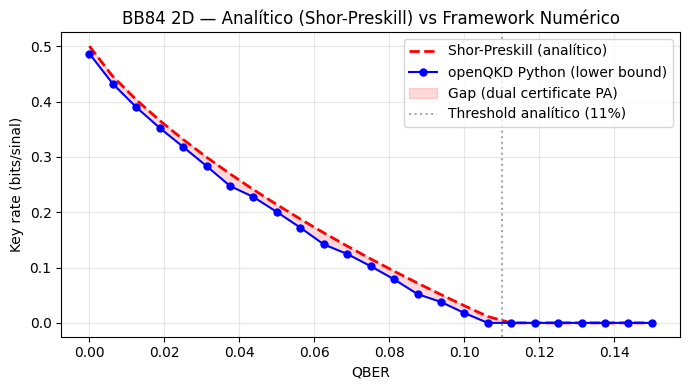

In [3]:
import sys
sys.path.insert(0, r"C:\\Users\\Mario\\Documents\\OpenQKD\\openqkd_python")

import numpy as np
import matplotlib.pyplot as plt
from openqkd.presets.bb84_preset import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration

# ── Entropia binária ────────────────────────────────────────────────────────
def h(e):
    if e <= 0 or e >= 1:
        return 0.0
    return -e * np.log2(e) - (1 - e) * np.log2(1 - e)

# ── Sweep numérico (framework) ──────────────────────────────────────────────
error_rates = np.linspace(0.0, 0.15, 25)
key_rates   = []

for e in error_rates:
    qkd = BasicBB84Alice2DPreset(error_rate=e)
    r   = MainIteration(qkd)
    kr  = max(0.0, r["key_rate"])
    key_rates.append(kr)
    print(f"  e={e:.4f} | QBER_Z={r['qber_Z']:.4f} | "
          f"leak_EC={r['leak_ec']:.4f} | key_rate={kr:.6f}")

key_rates = np.array(key_rates)

# ── Curva analítica: Shor-Preskill com sifting q = 1/2 ─────────────────────
# r = (1/2) * (1 - 2h(e))  [mesma normalização por sinal transmitido]
kr_sp = np.array([max(0.0, 0.5 * (1 - 2 * h(e))) for e in error_rates])

# ── Threshold ───────────────────────────────────────────────────────────────
threshold_idx = next(i for i, kr in enumerate(key_rates) if kr == 0.0)
print(f"\n  Threshold QBER ≈ {error_rates[threshold_idx-1]:.4f} (esperado ~0.110)")

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))

plt.plot(error_rates, kr_sp,
         'r--', linewidth=2, label="Shor-Preskill (analítico)")

plt.plot(error_rates, key_rates,
         'b-o', markersize=5, label="openQKD Python (lower bound)")

plt.fill_between(error_rates, key_rates, kr_sp,
                 alpha=0.15, color='red', label="Gap (dual certificate PA)")

plt.axvline(0.11, color='gray', linestyle=':', alpha=0.7, label="Threshold analítico (11%)")

plt.xlabel("QBER")
plt.ylabel("Key rate (bits/sinal)")
plt.title("BB84 2D — Analítico (Shor-Preskill) vs Framework Numérico")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("bb84_comparison.png", dpi=150)
plt.show()
